Ajuste o modelo para que obtenha uma redução do loss e um aumento da accuracy

Dataset: https://www.kaggle.com/code/divthecreator/heart-disease-predictions

In [4]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
!pip install -q kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/ 2>/dev/null # This line is only needed if you manually uploaded the file
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null

In [5]:
!kaggle datasets download data855/heart-disease


Dataset URL: https://www.kaggle.com/datasets/data855/heart-disease
License(s): CC0-1.0
100% 3.40k/3.40k [00:00<00:00, 4.97MB/s]



In [1]:
from google.colab import drive

drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [2]:
import zipfile
import io
zip_file_name = '/content/heart-disease.zip' # Replace with the actual zip file name
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Datasets/heart') # Extract to the content directory

In [5]:
data = pd.read_csv("/content/drive/MyDrive/Datasets/heart/heart.csv", index_col=None)


In [6]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [7]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [8]:
data['chol']

,chol
0,233
1,250
2,204
3,236
4,354
...,...
298,241
299,264
300,193
301,131


In [9]:
data['chol'].describe()

,chol
count,303.000000
mean,246.264026
std,51.830751
min,126.000000
25%,211.000000
50%,240.000000
75%,274.500000
max,564.000000


In [10]:
#discretização

def filter(x):
    if x <= 126:
        return 'low chol'
    if (x > 126 and x <= 211):
        return 'medium chol'
    if (x > 211 and x <= 274.5):
        return 'limiar chol'
    elif(x > 274.5):
      return 'high chol'

data['chol_cat'] = data['chol'].apply(filter)

In [11]:
data[['chol', 'chol_cat']]

,chol,chol_cat
0,233,limiar chol
1,250,limiar chol
2,204,medium chol
3,236,limiar chol
4,354,high chol
...,...,...
298,241,limiar chol
299,264,limiar chol
300,193,medium chol
301,131,medium chol


In [12]:
data[ 'chol_cat'].value_counts()

,count
chol_cat,
limiar chol,149
medium chol,77
high chol,76
low chol,1


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X, y = data[['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']], data['chol_cat']

X = np.asarray(X).astype('float32')

X = np.nan_to_num(X, nan=0)

In [15]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11
0,63.0,1.0,3.0,145.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0
1,37.0,1.0,2.0,130.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0
2,41.0,0.0,1.0,130.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0
3,56.0,1.0,1.0,120.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0
4,57.0,0.0,0.0,120.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
298,57.0,0.0,0.0,140.0,0.0,1.0,123.0,1.0,0.2,1.0,0.0,3.0
299,45.0,1.0,3.0,110.0,0.0,1.0,132.0,0.0,1.2,1.0,0.0,3.0
300,68.0,1.0,0.0,144.0,1.0,1.0,141.0,0.0,3.4,1.0,2.0,3.0
301,57.0,1.0,0.0,130.0,0.0,1.0,115.0,1.0,1.2,1.0,1.0,3.0


In [16]:
from sklearn import preprocessing

min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(x_scaled)

In [17]:
X

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.708333,1.0,1.000000,0.481132,1.0,0.0,0.603053,0.0,0.370968,0.0,0.00,0.333333
1,0.166667,1.0,0.666667,0.339623,0.0,0.5,0.885496,0.0,0.564516,0.0,0.00,0.666667
2,0.250000,0.0,0.333333,0.339623,0.0,0.0,0.770992,0.0,0.225806,1.0,0.00,0.666667
3,0.562500,1.0,0.333333,0.245283,0.0,0.5,0.816794,0.0,0.129032,1.0,0.00,0.666667
4,0.583333,0.0,0.000000,0.245283,0.0,0.5,0.702290,1.0,0.096774,1.0,0.00,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.583333,0.0,0.000000,0.433962,0.0,0.5,0.396947,1.0,0.032258,0.5,0.00,1.000000
299,0.333333,1.0,1.000000,0.150943,0.0,0.5,0.465649,0.0,0.193548,0.5,0.00,1.000000
300,0.812500,1.0,0.000000,0.471698,1.0,0.5,0.534351,0.0,0.548387,0.5,0.50,1.000000
301,0.583333,1.0,0.000000,0.339623,0.0,0.5,0.335878,1.0,0.193548,0.5,0.25,1.000000


In [18]:
categories = y.astype('category').cat.categories


In [19]:
categories

Index(['high chol', 'limiar chol', 'low chol', 'medium chol'], dtype='object')

In [20]:
y = y.astype('category').cat.codes
y = np.asarray(y).astype('int')
y

array([1, 1, 3, 1, 0, 3, 0, 1, 3, 3, 1, 0, 1, 3, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 3, 0, 1, 3, 0, 3, 3, 3, 1, 1, 1, 3, 0, 1, 1, 0, 0, 1, 3, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 3, 1, 3, 1, 1, 3, 0, 1, 0, 3, 3, 3, 3,
       1, 1, 1, 3, 1, 1, 3, 1, 1, 1, 1, 1, 3, 1, 1, 0, 0, 0, 1, 0, 0, 3,
       1, 1, 1, 3, 1, 0, 3, 1, 0, 1, 0, 1, 1, 1, 3, 1, 3, 3, 1, 1, 1, 1,
       0, 2, 0, 3, 1, 1, 1, 3, 3, 1, 0, 1, 1, 1, 3, 3, 3, 0, 3, 1, 3, 1,
       0, 1, 0, 1, 3, 3, 3, 1, 0, 0, 3, 1, 3, 1, 1, 1, 1, 3, 1, 3, 1, 0,
       1, 3, 1, 3, 1, 1, 1, 0, 3, 3, 3, 0, 1, 1, 1, 3, 1, 1, 0, 1, 3, 3,
       1, 0, 3, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 3, 0, 1, 3, 0, 3, 0, 1, 1,
       1, 1, 3, 1, 1, 1, 3, 1, 1, 1, 3, 3, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 3, 0, 3, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 3, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 3, 1, 1, 1, 1, 0, 1,
       3, 1, 0, 3, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 3, 0, 3, 1, 1, 3, 0,
       3, 1, 0, 3, 3, 0, 1, 1, 3, 3, 3, 3, 1, 1, 3,

In [21]:
import tensorflow as tf
y = tf.keras.utils.to_categorical(y, 4)

In [22]:
y

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [23]:

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

#x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.5)

print('Shape de x_train', x_train.shape)
#print('Shape de x_val', x_val.shape)
print('Shape de x_test', x_test.shape)

print('Shape de y_train', y_train.shape)
#print('Shape de y_val', y_val.shape)
print('Shape de y_test', y_test.shape)


Shape de x_train (242, 12)
Shape de x_test (61, 12)
Shape de y_train (242, 4)
Shape de y_test (61, 4)


In [24]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Input, Dropout, BatchNormalization


In [25]:
# AUC-PR multiclasse (One-vs-Rest)
auc_pr = tf.keras.metrics.AUC(
    curve='PR',
    multi_label=True,   # necessário para multiclasse
    num_labels=4,
    name='auc_pr'
)


In [26]:
model = Sequential()
model.add(Dense(64, input_shape=(12,), activation='relu'))
#model.add(BatchNormalization())
#model.add(Input(16, shape=(74,), activation="relu"))
model.add(Dense(256, activation='relu'))
# model.add(Dense(256, activation="sigmoid"))
model.add(Dense(128, activation="sigmoid"))
#model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(64, activation="relu"))
#model.add(Dropout(0.5))
# model.add(BatchNormalization())
# model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=[auc_pr])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,396 (232.02 KB)

 Trainable params: 59,140 (231.02 KB)

 Non-trainable params: 256 (1.00 KB)

In [28]:
x_train.shape

(242, 12)

In [29]:
y_train

array([[0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],


In [30]:
from tensorflow.keras.callbacks import EarlyStopping

# Definindo o Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # métrica monitorada
    patience=10,           # número de épocas sem melhora antes de parar
    restore_best_weights=True  # restaura os melhores pesos ao final
)

In [31]:
from keras.callbacks import ReduceLROnPlateau

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # reduz pela metade
    patience=3,
    min_lr=1e-6
)

In [32]:
batch_size = 16
epochs = 100

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1)

#callbacks=[early_stopping, lr_reduction]

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - auc_pr: 0.2470 - loss: 1.3065 
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.4175 - loss: 1.0301 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.4363 - loss: 0.9691 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.4360 - loss: 0.9439 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.4737 - loss: 0.9050 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc_pr: 0.4788 - loss: 0.8664
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5394 - loss: 0.8061 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc_pr: 0.5179 - loss: 0.8240
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5487 - loss: 0.7577 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5552 - loss: 0.7558 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5688 - loss: 0.7342 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc_pr: 0.5673 - loss:

KeyError: 'val_loss'

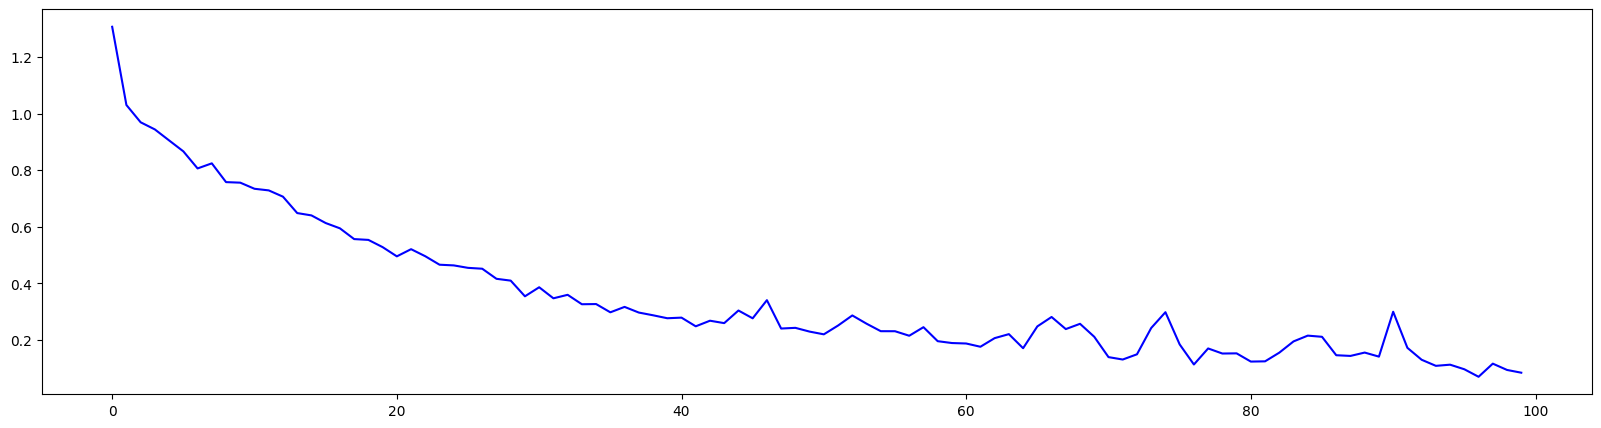

In [38]:
import matplotlib.pyplot as plt

# Plotando o historico do processo de treinamento
plt.figure(figsize=(20, 5))
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.title('Model loss', fontsize=20)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Treinamento', 'Validação'], loc='upper right', fontsize=14)
plt.show()


import matplotlib.pyplot as plt

# Plotando o historico do processo de treinamento
plt.figure(figsize=(20, 5))
plt.plot(history.history['accuracy'], color='blue')
plt.plot(history.history['val_accuracy'], color='red')
plt.title('Model accuracy', fontsize=20)
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Treinamento', 'Validação'], loc='upper right', fontsize=14)
plt.show()

In [37]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test auc_pr:', score[1])

Test loss: 3.304346799850464
Test auc_pr: 0.22145777940750122


In [47]:
np.array(x_test.iloc[0]).reshape(1,12)

array([[0.8541667 , 1.        , 0.        , 0.4811321 , 0.        ,
        0.5       , 0.41221374, 1.        , 0.41935486, 0.        ,
        0.        , 1.        ]], dtype=float32)

In [48]:
x_new = np.array(x_test.iloc[0]).reshape(1,12)

x_new.shape

(1, 12)

In [49]:
pred = model.predict(x_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [50]:
pred

array([[4.5138064e-01, 5.4837567e-01, 3.2863412e-05, 2.1088491e-04]],
      dtype=float32)

In [51]:
categories[pred.argmax()]

'limiar chol'

In [58]:
categories[y[0].argmax()]

'limiar chol'

# Salvar modelo

In [61]:
model.save("heart.keras")


In [63]:
import keras

loaded_model = keras.saving.load_model("heart.keras")

In [64]:
pred = loaded_model.predict(x_new)

categories[pred.argmax()]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step


'limiar chol'